<a href="https://colab.research.google.com/github/Bunty-Bot/deep_learning_MBFProject/blob/main/DL_MBFProject_simulated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
# Importing all the required libraries
import os
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
from torch.utils.data import RandomSampler
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
import copy
import wandb

In [78]:
# Cloning the git repository with the Data
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 6.21 MiB/s, done.


#Data Loading

In [79]:
# Analysing the data structure for further analysis
seqfile = "len100_200_n1000.seq"
posfile = "len100_200_n1000.pos"

print("First 5 entries from seqfile:")
with open(seqfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

print("\nFirst 5 entries from posfile:")
with open(posfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

First 5 entries from seqfile:
seq1	MQICGLVKTAKTPSCWSTVPYGREVGSPMTHQQHETERLQYKRWSGCNGFHGGKIRQYLFNMQGTDCKTDQTAGMAISESFLDFQGDHSYEELNAHPIFQTWPPNNSIRDDCL
seq2	MTGVKGTYGTPNVFQSTNEVSSGDQKIPWPKTEQTACLWGLPLSQFPIRKVIREIDNANTAIINLSLQDPNGNCNCMSKDSYTWWFRYARFHRCGRCIWMPWNGDRCDKYEKYYTDNMLYPEPNQLDSDRIKRGACHSDGMTDHGRDNGKWCCFVINLDDPSHTLP
seq3	MCHYAWCMWNTGCHWGINEEWAFHDKDLQGFPRKLHRPTRPKHYDTCLDDFSMCSTMCEARNVQRYNNWDRVRNRSQNVFDSYQDISRRAHFDSRQDDVLTDTKCYTNEFCHCELSPDMLFLGRTPNTSQAKPHIHVITRPNCNCHPRNQWATMIYYQWKLRQESETVIDQNKGCFSIFAKKEAGTWGIEFTLLYAK
seq4	MQVLNSMLDKVTQDWGKKCGLVKTAKTPQFWILVRRNPSVPVAAAMSINCFSTPRHELYKVRMMGWGSLYKNRQTYNSLSTLMRHSSMPSGVTDCVYWAVFGESIDDDWAWWLRADNDFLWFGNDTDRSIGLYINSCSRVDWMWANHFSE
seq5	MKNHQGCCPSTVGFRNDAQYQISWDVPMAWLWLDRPVKLYMFHFDTEMRDHFKIQSRVNQPDTYPVETTEPFAMVREPEAWSVTNRWSQNSRTWRNMCNTLIINNFEKYDANYVWRWQYWWERQGKRLPHWLPC

First 5 entries from posfile:
seq1
seq4
seq7
seq9
seq10


In [80]:
def read(seqfile, posfile):
    """
    Read a dataset from provided sequence and positive file.

    Args:
        seqfile : sequence file with one sequence per line
        posfile : list of positive IDs (one per line)

    Returns:
        sequences : list[str]   amino acid sequences
        labels    : list[int]   1 = functional,  0 = not functional
    """
    seq_dict = {}

    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Using regex function extracting the sequence
            match = re.match(r"(seq\d+)\t([A-Z]+)", line)
            if not match:
                continue

            pid, seq = match.groups()

            if pid in seq_dict:
                raise ValueError(f"Duplicate ID found: {pid}")

            seq_dict[pid] = seq

    pos_ids = set()
    with open(posfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    sequences = []
    labels = []

    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    return sequences, labels

In [81]:
def plot_label_distribution(labels,title="Positive and Negative samples in the Data"):
    """
    Plot the distribution of positive and negative labels.

    Args:
        labels (list[int]): Binary labels where 1 = positive and 0 = negative.
        title (str): Plot title.

    Returns:
        None. Displays the bar chart.
    """
    if len(labels) == 0:
        raise ValueError("labels is empty; cannot plot class distribution.")

    counts = [sum(labels), len(labels) - sum(labels)]
    total = len(labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(
        ["Positive (functional)", "Negative (not functional)"],
        counts,
        color=["#2a9d8f", "#e76f51"],
        edgecolor="white",
        linewidth=0.8,
    )

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({100 * count / total:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11,
        )

    ax.set_ylabel("Number of sequences")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.show()

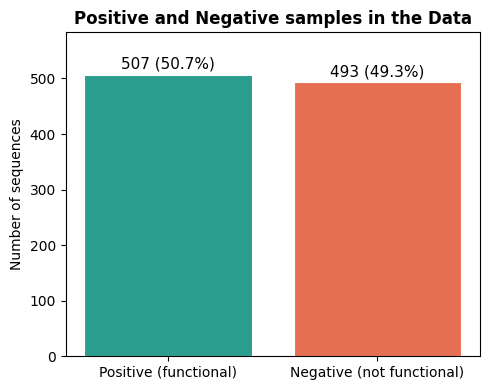

In [82]:
seq, label = read(seqfile, posfile)
plot_label_distribution(label)


#Data Preprocessing

In [83]:
def generate_train_val_test(datalist, labellist, random_state=42):
    """
    Split data into train, validation, and test sets using a 70/15/15 split.

    Args:
        datalist: List of sequences.
        labellist (list): List of binary labels.
        random_state (int): Seed for reproducibility.

    Returns:
        train_seq, train_lab, val_seq, val_lab, test_seq, test_lab
    """
    if len(datalist) != len(labellist):
        raise ValueError("datalist and labellist must have the same length")
    if len(datalist) == 0:
        raise ValueError("Input data is empty")

    # Step 1: split train (70%) vs temp (30%)
    seq_train, seq_temp, lab_train, lab_temp = train_test_split(
        datalist, labellist,
        test_size=0.30,
        random_state=random_state,
        stratify=labellist
    )

    # Step 2: split temp 50/50 → 15% val, 15% test
    seq_val, seq_test, lab_val, lab_test = train_test_split(
        seq_temp, lab_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=lab_temp
    )

    # Print exact counts
    print(f"Train: {len(seq_train)} sequences, {sum(lab_train)} positive")
    print(f"Val  : {len(seq_val)} sequences, {sum(lab_val)} positive")
    print(f"Test : {len(seq_test)} sequences, {sum(lab_test)} positive")
    print(f"Total: {len(datalist)} sequences")

    return seq_train, lab_train, seq_val, lab_val, seq_test, lab_test

In [84]:
def tokenize(datalist, map2num, non_aa_num=20):
    """Convert sequences to numbers for neural net."""
    seqs = []
    for sequence in datalist:
        seqs.append([map2num.get(aa, non_aa_num) for aa in sequence])
    return seqs

In [85]:
def truncate_pad(line, num_steps, padding_token=20):
    """Truncate or pad a sequence to exactly num_steps."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

In [86]:
def build_seq_array(lines, num_steps):
    """Stack all sequences into one integer tensor [N, num_steps]."""
    array = torch.tensor([truncate_pad(l, num_steps) for l in lines])
    return array

#Train model using embedding method

In [87]:
class CNN1D(nn.Module):
    def __init__(self, vocab_size, context_size, conv_channels=128,
                 use_bias=False, dropout=0.0):   # <-- add dropout param
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, 64, padding_idx=vocab_size)

        self.cnn = nn.Sequential(
            nn.Conv1d(64, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),          # <-- add dropout
            nn.MaxPool1d(2, 2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),          # <-- add dropout
            nn.MaxPool1d(2, 2),
            nn.Flatten(1, -1),
            nn.Linear(int(conv_channels * context_size / 4), 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = self.embedding(X).transpose(1, 2)
        logits = self.cnn(x).squeeze(1)
        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())
        return logits, loss

In [88]:
class SequenceDataset(TensorDataset):
    vocab_size    = 20
    padding_token = 20  # unknown/padding index

    def __init__(self, sequences, labels, context_size=200):
        mapaa2num = {aa: i for i, aa in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}
        tokenized = tokenize(sequences, mapaa2num, non_aa_num=self.padding_token)  # your existing function!
        self.X = torch.tensor([self._pad(t, context_size) for t in tokenized], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def _pad(self, tokens, context_size):
        tokens = tokens[:context_size]
        tokens += [self.padding_token] * (context_size - len(tokens))
        return tokens

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [89]:
context_size = 200
batch_size = 64
EPOCHS = 12
patience = 3
dropout = 0.3 # Define dropout for wandb logging and model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

train_dataset = SequenceDataset(seq_train, lab_train, context_size)
val_dataset   = SequenceDataset(seq_val, lab_val, context_size)
test_dataset  = SequenceDataset(seq_test, lab_test, context_size)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader  = DataLoader(test_dataset, batch_size=batch_size)

model = CNN1D(
    vocab_size=SequenceDataset.vocab_size,
    context_size=context_size,
    conv_channels=32,
    dropout=dropout # Use the defined dropout variable
).to(DEVICE)

lr = 1e-3 # Define learning rate for wandb logging
weight_decay = 1e-2 # Define weight decay for wandb logging
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

wandb.init(
    project="protein-simulated-data",
    name=f"cnn_embedded",
    config={
        "model": "CNN1D",
        "context_size": context_size,
        "batch_size": batch_size,
        "epochs": EPOCHS,
        "patience": patience,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "optimizer": "AdamW",
    }
)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
wait = 0

for epoch in range(EPOCHS):
    model.train()
    train_epoch_losses = []
    train_preds, train_true = [], []

    for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits, loss = model(x, y)
        loss.backward()
        optimizer.step()

        train_epoch_losses.append(loss.item())
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        train_preds.extend(preds)
        train_true.extend(y.cpu().numpy())

    model.eval()
    val_epoch_losses = []
    val_preds, val_true = [], []

    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, val_loss = model(x, y)
            val_epoch_losses.append(val_loss.item())
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            val_preds.extend(preds)
            val_true.extend(y.cpu().numpy())

    avg_train_loss = np.mean(train_epoch_losses)
    avg_val_loss = np.mean(val_epoch_losses)
    train_acc = accuracy_score(train_true, train_preds)
    val_acc = accuracy_score(val_true, val_preds)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "learning_rate": optimizer.param_groups[0]["lr"],
    })

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    if avg_val_loss < best_val_loss - 1e-3:
        best_val_loss = avg_val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

# The plotting code has been removed as it will be handled by wandb or a separate cell if needed.

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


epoch,▁▂▂▃▄▄▅▅▆▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▃▄▆▆▆▇▇▇██
train_loss,██▇▇▆▅▅▃▃▂▁▁
val_accuracy,▁▁▂▂▃▅▅▅▅▇██
val_loss,████▇▇▆▅▇▃▃▁
epoch,12
learning_rate,0.001
train_accuracy,0.89429
train_loss,0.30332
val_accuracy,0.79333


Epoch 1/12: 100%|██████████| 11/11 [00:00<00:00, 192.77it/s]


Epoch 1: train_loss=0.6978, val_loss=0.6988, train_acc=0.4943, val_acc=0.4800


Epoch 2/12: 100%|██████████| 11/11 [00:00<00:00, 190.55it/s]


...

Epoch 11/12: 100%|██████████| 11/11 [00:00<00:00, 150.22it/s]


Epoch 11: train_loss=0.2586, val_loss=0.4059, train_acc=0.9200, val_acc=0.8533


Epoch 12/12: 100%|██████████| 11/11 [00:00<00:00, 179.66it/s]

Epoch 12: train_loss=0.2412, val_loss=0.3708, train_acc=0.9129, val_acc=0.8400


<All keys matched successfully>

In [90]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=64)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n--- {name} Accuracy: {acc:.4f} ---")
    print(classification_report(all_labels, all_preds, target_names=['Non-functional', 'Functional']))

# Run on train, val and test
evaluate_accuracy(model, train_dataset, "Train", DEVICE)
evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)


--- Train Accuracy: 0.9700 ---
                precision    recall  f1-score   support

Non-functional       0.99      0.94      0.97       345
    Functional       0.95      0.99      0.97       355

      accuracy                           0.97       700
     macro avg       0.97      0.97      0.97       700
  weighted avg       0.97      0.97      0.97       700


--- Validation Accuracy: 0.8400 ---
                precision    recall  f1-score   support

Non-functional       0.90      0.76      0.82        74
    Functional       0.80      0.92      0.85        76

      accuracy                           0.84       150
     macro avg       0.85      0.84      0.84       150
  weighted avg       0.85      0.84      0.84       150



In [91]:
evaluate_accuracy(model, test_dataset,  "Test", DEVICE)


--- Test Accuracy: 0.8533 ---
                precision    recall  f1-score   support

Non-functional       0.89      0.80      0.84        74
    Functional       0.82      0.91      0.86        76

      accuracy                           0.85       150
     macro avg       0.86      0.85      0.85       150
  weighted avg       0.86      0.85      0.85       150



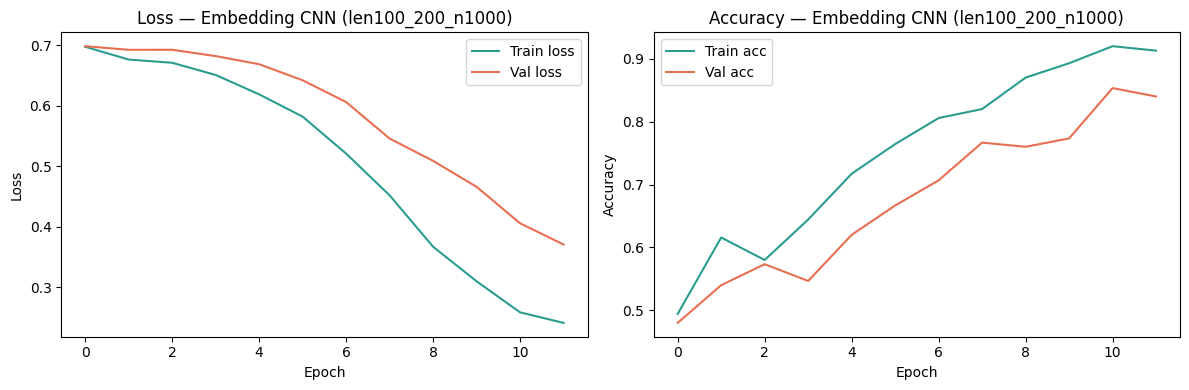

In [92]:
# Plot training curves for the embedding CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses,      label="Train loss",  color="#2a9d8f")
ax1.plot(val_losses,        label="Val loss",    color="#e76f51")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss — Embedding CNN (len100_200_n1000)")
ax1.legend()

ax2.plot(train_accuracies,  label="Train acc",   color="#2a9d8f")
ax2.plot(val_accuracies,    label="Val acc",     color="#e76f51")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy — Embedding CNN (len100_200_n1000)")
ax2.legend()

plt.tight_layout()
plt.show()

## Hyperparameter Sweep — Dropout and Learning Rate
We test three dropout values and three learning rates on `len100_200_n1000` to find the best settings before scaling to larger datasets.

In [93]:
import itertools, copy
import pandas as pd

dropout_values = [0.1, 0.3, 0.5]
lr_values      = [1e-4, 1e-3, 3e-3]
SWEEP_EPOCHS   = 12
SWEEP_PATIENCE = 3

sweep_results = []

for dr, lr in itertools.product(dropout_values, lr_values):
    seq, label = read(seqfile, posfile)
    seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

    tr_ds = SequenceDataset(seq_train, lab_train, context_size)
    vl_ds = SequenceDataset(seq_val,   lab_val,   context_size)
    te_ds = SequenceDataset(seq_test,  lab_test,  context_size)

    tr_dl = DataLoader(tr_ds, batch_size=64, shuffle=True)
    vl_dl = DataLoader(vl_ds, batch_size=64)

    m = CNN1D(vocab_size=SequenceDataset.vocab_size, context_size=context_size, conv_channels=32, dropout=dr).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-2)

    best_val_loss = float("inf")
    best_state    = copy.deepcopy(m.state_dict())
    wait          = 0

    for epoch in range(SWEEP_EPOCHS):
        m.train()
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            _, loss = m(x, y)
            loss.backward()
            opt.step()

        m.eval()
        val_losses_ep = []
        with torch.no_grad():
            for x, y in vl_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                _, vloss = m(x, y)
                val_losses_ep.append(vloss.item())
        vl = np.mean(val_losses_ep)

        if vl < best_val_loss:
            best_val_loss = vl
            best_state    = copy.deepcopy(m.state_dict())
            wait = 0
        else:
            wait += 1
        if wait >= SWEEP_PATIENCE: break

    m.load_state_dict(best_state)

    def quick_acc(model, ds):
        loader = DataLoader(ds, batch_size=64)
        preds, trues = [], []
        model.eval()
        with torch.no_grad():
            for x, y in loader:
                logits, _ = model(x.to(DEVICE))
                preds.extend((torch.sigmoid(logits) > 0.5).cpu().numpy())
                trues.extend(y.numpy())
        return accuracy_score(trues, preds)

    sweep_results.append({
        "dropout": dr, "lr": lr,
        "val_acc": round(quick_acc(m, vl_ds), 4),
        "test_acc": round(quick_acc(m, te_ds), 4)
    })

sweep_df = pd.DataFrame(sweep_results)
display(sweep_df)
BEST_DROPOUT = sweep_df.loc[sweep_df["val_acc"].idxmax()]["dropout"]
BEST_LR = sweep_df.loc[sweep_df["val_acc"].idxmax()]["lr"]

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


,dropout,lr,val_acc,test_acc
0,0.1,0.0001,0.5400,0.6200
1,0.1,0.0010,0.8467,0.8667
2,0.1,0.0030,0.9933,0.9933
3,0.3,0.0001,0.5533,0.5667
4,0.3,0.0010,0.8267,0.8600
5,0.3,0.0030,0.9867,0.9933
6,0.5,0.0001,0.5533,0.4533
7,0.5,0.0010,0.8600,0.8533
8,0.5,0.0030,1.0000,0.9867


## Positive vs Negative Subsampling
We investigate performance when removing half of the functional (positive) or non-functional (negative) sequences from the training set.

In [94]:
import random

def subsample_train(seq_tr, lab_tr, remove="positives", fraction=0.5):
    random.seed(42)
    pos_idx = [i for i, l in enumerate(lab_tr) if l == 1]
    neg_idx = [i for i, l in enumerate(lab_tr) if l == 0]
    drop_pool = pos_idx if remove == "positives" else neg_idx
    drop_set = set(random.sample(drop_pool, int(len(drop_pool) * fraction)))
    keep = [i for i in range(len(lab_tr)) if i not in drop_set]
    return [seq_tr[i] for i in keep], [lab_tr[i] for i in keep]

def train_and_eval(s_tr, l_tr, s_vl, l_vl, s_te, l_te, dr, lr, ctx=200):
    # Use SequenceDatasetOneHot to match the current CNN1D architecture
    tr_ds = SequenceDatasetOneHot(s_tr, l_tr, ctx)
    vl_ds = SequenceDatasetOneHot(s_vl, l_vl, ctx)
    te_ds = SequenceDatasetOneHot(s_te, l_te, ctx)

    tr_dl = DataLoader(tr_ds, batch_size=64, shuffle=True)
    # Updated to use CNN1DOneHot
    m = CNN1DOneHot(context_size=ctx, conv_channels=32, dropout=dr).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)

    for epoch in range(12):
        m.train()
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            _, loss = m(x, y)
            loss.backward()
            opt.step()

    def acc(ds):
        m.eval()
        p, t = [], []
        with torch.no_grad():
            for x, y in DataLoader(ds, batch_size=64):
                logits, _ = m(x.to(DEVICE))
                p.extend((torch.sigmoid(logits) > 0.5).cpu().numpy())
                t.extend(y.numpy())
        return accuracy_score(t, p)

    return round(acc(vl_ds), 4), round(acc(te_ds), 4)

In [95]:
# -- Run the three conditions --
seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = \
    generate_train_val_test(seq, label)

conditions = {
    "Full training set":       (seq_train, lab_train),
    "Half positives removed":  subsample_train(seq_train, lab_train, remove="positives"),
    "Half negatives removed":  subsample_train(seq_train, lab_train, remove="negatives"),
}

subsample_results = []
for name, (s_tr, l_tr) in conditions.items():
    n_pos = sum(l_tr)
    n_neg = len(l_tr) - n_pos
    val_acc, test_acc = train_and_eval(
        s_tr, l_tr, seq_val, lab_val, seq_test, lab_test,
        dr=BEST_DROPOUT, lr=BEST_LR, ctx=200
    )
    subsample_results.append({
        "condition":       name,
        "train_pos":       n_pos,
        "train_neg":       n_neg,
        "val_acc":         val_acc,
        "test_acc":        test_acc,
    })
    print(f"{name:30s}  pos={n_pos}  neg={n_neg}  val={val_acc:.4f}  test={test_acc:.4f}")

print("\n=== Subsampling Results ===")
print(pd.DataFrame(subsample_results).to_string(index=False))

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
Full training set               pos=355  neg=345  val=0.9867  test=0.9867
Half positives removed          pos=178  neg=345  val=0.4933  test=0.4933
Half negatives removed          pos=355  neg=173  val=0.7333  test=0.7133

=== Subsampling Results ===
             condition  train_pos  train_neg  val_acc  test_acc
     Full training set        355        345   0.9867    0.9867
Half positives removed        178        345   0.4933    0.4933
Half negatives removed        355        173   0.7333    0.7133


#Train model using One-Hot Encoding method

In [96]:
class SequenceDatasetOneHot(TensorDataset):
    vocab_size = 20
    padding_token = 20

    def __init__(self, sequences, labels, context_size=200):
        self.context_size = context_size
        self.X = torch.tensor(self.tokenize_onehot(sequences, context_size), dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def tokenize_onehot(self, datalist, max_length=200):
        aa_list = "ACDEFGHIKLMNPQRSTVWY"
        aa_map = {aa: i for i, aa in enumerate(aa_list)}
        encoded = []

        for sequence in datalist:
            row = [[0] * 20 for _ in range(max_length)]
            for i, aa in enumerate(sequence[:max_length]):
                if aa in aa_map:
                    row[i][aa_map[aa]] = 1
            encoded.append(row)

        return encoded

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [97]:
class CNN1DOneHot(nn.Module):
    def __init__(self, context_size, conv_channels=128, use_bias=False, dropout=0.0):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(20, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),

            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),

            nn.Flatten(1, -1),
            nn.Linear(int(conv_channels * context_size / 4), 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = X.transpose(1, 2)   # (batch, 20, context_size)
        logits = self.cnn(x).squeeze(1)

        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())

        return logits, loss

In [98]:
context_size = 200
batch_size = 64
EPOCHS = 12
patience = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

train_dataset = SequenceDatasetOneHot(seq_train, lab_train, context_size)
val_dataset   = SequenceDatasetOneHot(seq_val, lab_val, context_size)
test_dataset  = SequenceDatasetOneHot(seq_test, lab_test, context_size)

model = CNN1DOneHot(context_size=context_size, dropout=0.3).to(DEVICE)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader  = DataLoader(test_dataset, batch_size=batch_size)

lr = 1e-3 # Define learning rate for wandb logging
weight_decay = 1e-2 # Define weight decay for wandb logging
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

wandb.init(
    project="protein-simulated-data",
    name=f"cnn_onehot",
    config={
        "model": "CNN1DOneHot",
        "context_size": context_size,
        "epochs": EPOCHS,
        "patience": patience,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "optimizer": "AdamW",
    }
)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
wait = 0

for epoch in range(EPOCHS):
    model.train()
    train_epoch_losses = []
    train_preds, train_true = [], []

    for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits, loss = model(x, y)
        loss.backward()
        optimizer.step()

        train_epoch_losses.append(loss.item())
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        train_preds.extend(preds)
        train_true.extend(y.cpu().numpy())

    model.eval()
    val_epoch_losses = []
    val_preds, val_true = [], []

    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, val_loss = model(x, y)
            val_epoch_losses.append(val_loss.item())
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            val_preds.extend(preds)
            val_true.extend(y.cpu().numpy())

    avg_train_loss = np.mean(train_epoch_losses)
    avg_val_loss = np.mean(val_epoch_losses)
    train_acc = accuracy_score(train_true, train_preds)
    val_acc = accuracy_score(val_true, val_preds)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "learning_rate": optimizer.param_groups[0]["lr"],
    })

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    if avg_val_loss < best_val_loss - 1e-3:
        best_val_loss = avg_val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


epoch,▁▂▂▃▄▄▅▅▆▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▂▃▅▅▆▆▇███
train_loss,███▇▇▆▅▄▃▂▁▁
val_accuracy,▁▂▃▂▄▅▅▆▆▆██
val_loss,████▇▇▆▅▄▃▂▁
epoch,12
learning_rate,0.001
train_accuracy,0.91286
train_loss,0.24117
val_accuracy,0.84


Epoch 1/12: 100%|██████████| 11/11 [00:00<00:00, 219.39it/s]


Epoch 1: train_loss=0.6957, val_loss=0.6937, train_acc=0.5443, val_acc=0.5067


Epoch 2/12: 100%|██████████| 11/11 [00:00<00:00, 224.41it/s]


...

Epoch 11/12: 100%|██████████| 11/11 [00:00<00:00, 254.92it/s]


Epoch 11: train_loss=0.2031, val_loss=0.2799, train_acc=0.9529, val_acc=0.9400


Epoch 12/12: 100%|██████████| 11/11 [00:00<00:00, 250.28it/s]

Epoch 12: train_loss=0.1501, val_loss=0.2270, train_acc=0.9714, val_acc=0.9533


<All keys matched successfully>

In [99]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=64)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n--- {name} Accuracy: {acc:.4f} ---")
    print(classification_report(all_labels, all_preds, target_names=['Non-functional', 'Functional']))

# Run on train, val and test
evaluate_accuracy(model, train_dataset, "Train", DEVICE)
evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)


--- Train Accuracy: 0.9929 ---
                precision    recall  f1-score   support

Non-functional       0.99      1.00      0.99       345
    Functional       1.00      0.99      0.99       355

      accuracy                           0.99       700
     macro avg       0.99      0.99      0.99       700
  weighted avg       0.99      0.99      0.99       700


--- Validation Accuracy: 0.9533 ---
                precision    recall  f1-score   support

Non-functional       0.92      0.99      0.95        74
    Functional       0.99      0.92      0.95        76

      accuracy                           0.95       150
     macro avg       0.95      0.95      0.95       150
  weighted avg       0.96      0.95      0.95       150



In [100]:
evaluate_accuracy(model, test_dataset,  "Test", DEVICE)


--- Test Accuracy: 0.9467 ---
                precision    recall  f1-score   support

Non-functional       0.91      0.99      0.95        74
    Functional       0.99      0.91      0.95        76

      accuracy                           0.95       150
     macro avg       0.95      0.95      0.95       150
  weighted avg       0.95      0.95      0.95       150



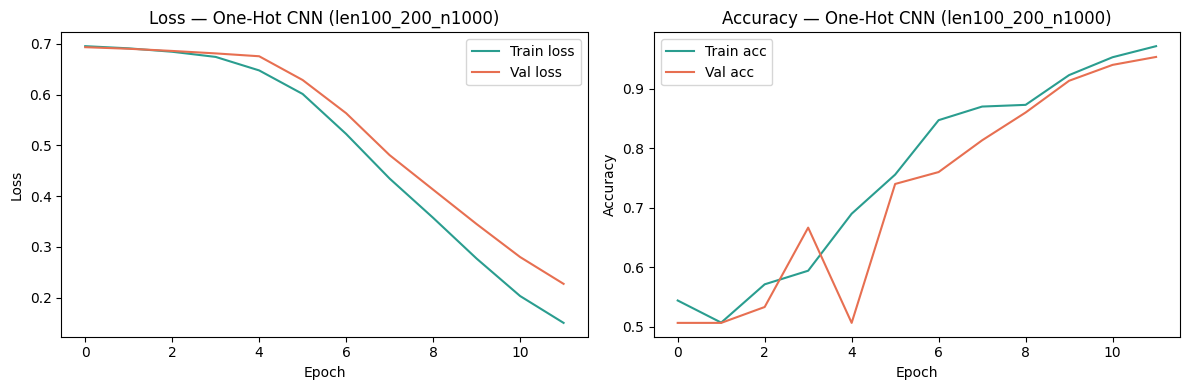

In [101]:
# Plot training curves for the one-hot CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses,      label="Train loss",  color="#2a9d8f")
ax1.plot(val_losses,        label="Val loss",    color="#e76f51")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss — One-Hot CNN (len100_200_n1000)")
ax1.legend()

ax2.plot(train_accuracies,  label="Train acc",   color="#2a9d8f")
ax2.plot(val_accuracies,    label="Val acc",     color="#e76f51")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy — One-Hot CNN (len100_200_n1000)")
ax2.legend()

plt.tight_layout()
plt.show()

## Scaling to All Simulated Datasets

In [102]:
all_datasets = [
    "len100_200_n1000",
    "len200_500_n1000",
    "len200_500_n5000nr1",
    "len200_500_n5000nr2",
    "len200_500_n5000nr3",
    "len200_500_n5000nr4",
]

all_results = []

for ds_name in all_datasets:
    seqfile_i = f"{ds_name}.seq"
    posfile_i = f"{ds_name}.pos"

    # sequences can be up to 500 aa for the larger datasets
    ctx = 500 if "200_500" in ds_name else 200

    seq_i, label_i = read(seqfile_i, posfile_i)
    seq_tr, lab_tr, seq_vl, lab_vl, seq_te, lab_te = \
        generate_train_val_test(seq_i, label_i)

    print(f"\n=== {ds_name} (context={ctx}) ===")

    # Passing arguments positionally to match the train_and_eval(s_tr, l_tr, s_vl, l_vl, s_te, l_te, dr, lr, ctx) signature
    val_acc, test_acc = train_and_eval(
        seq_tr, lab_tr, seq_vl, lab_vl, seq_te, lab_te,
        BEST_DROPOUT, BEST_LR, ctx
    )
    print(f"val_acc={val_acc:.4f}  test_acc={test_acc:.4f}")

    all_results.append({
        "dataset":   ds_name,
        "n_seqs":    len(seq_i),
        "context":   ctx,
        "dropout":   BEST_DROPOUT,
        "lr":        BEST_LR,
        "val_acc":   val_acc,
        "test_acc":  test_acc,
    })

print("\n=== Summary: All Simulated Datasets ===")
print(pd.DataFrame(all_results).to_string(index=False))

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences

=== len100_200_n1000 (context=200) ===
val_acc=0.9800  test_acc=0.9933
Train: 700 sequences, 344 positive
Val  : 150 sequences, 74 positive
Test : 150 sequences, 74 positive
Total: 1000 sequences

=== len200_500_n1000 (context=500) ===
val_acc=0.7600  test_acc=0.7200
Train: 3500 sequences, 1727 positive
Val  : 750 sequences, 370 positive
Test : 750 sequences, 370 positive
Total: 5000 sequences

=== len200_500_n5000nr1 (context=500) ===
val_acc=1.0000  test_acc=0.9987
Train: 3500 sequences, 1723 positive
Val  : 750 sequences, 369 positive
Test : 750 sequences, 369 positive
Total: 5000 sequences

=== len200_500_n5000nr2 (context=500) ===
val_acc=0.5507  test_acc=0.5680
Train: 3500 sequences, 1744 positive
Val  : 750 sequences, 374 positive
Test : 750 sequences, 373 positive
Total: 5000 sequences

=== len200_500_n5000nr3 (context=500) ===
val_acc=0.9987  test_acc=0